In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import ssl
import json
import urllib.request
import nibabel as nib
import pandas as pd
from IPython.display import Image, display

In [2]:
def run(cmd, cwd=None, check=True):
    env = os.environ.copy()
    env["USER"] = env.get("USER") or "jovyan"
    env["HOME"] = env.get("HOME") or "/home/jovyan"

    result = subprocess.run(
        cmd,
        cwd=cwd,
        text=True,
        capture_output=True,
        env=env,
    )
    if check and result.returncode != 0:
        raise RuntimeError(
            f"Command failed: {' '.join(cmd)}\n\nSTDOUT:\n{result.stdout}\n\nSTDERR:\n{result.stderr}"
        )
    return result

In [3]:
CTX = ssl._create_unverified_context()
OPENNEURO_API = "https://openneuro.org/crn/graphql"
DATASET_ID = "ds007486"
SNAPSHOT_TAG = "1.0.0"

def gql(query, variables):
    payload = json.dumps({"query": query, "variables": variables}).encode("utf-8")
    req = urllib.request.Request(
        OPENNEURO_API,
        data=payload,
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urllib.request.urlopen(req, context=CTX) as resp:
        return json.load(resp)

def snapshot_files(tree=None):
    query = """
    query($datasetId: ID!, $tag: String!, $tree: String) {
      snapshot(datasetId: $datasetId, tag: $tag) {
        files(tree: $tree) {
          key
          filename
          directory
          urls
          size
        }
      }
    }
    """
    return gql(query, {"datasetId": DATASET_ID, "tag": SNAPSHOT_TAG, "tree": tree})["data"]["snapshot"]["files"]

def subject_directory_key(subject, root_rows):
    for row in root_rows:
        if row.get("directory") and row["filename"] == subject:
            return row["key"]
    raise FileNotFoundError(f"Missing subject directory for {subject}")

def child_directory_key(parent_key, dirname):
    rows = snapshot_files(parent_key)
    for row in rows:
        if row.get("directory") and row["filename"] == dirname:
            return row["key"]
    raise FileNotFoundError(f"Missing child directory {dirname} under {parent_key}")

def file_url_map(tree_key):
    rows = snapshot_files(tree_key)
    return {row["filename"]: row["urls"][0] for row in rows if row.get("urls")}

def download_url(url, destination):
    destination.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(url, context=CTX) as resp:
        destination.write_bytes(resp.read())
    return destination

In [4]:
REPRESENTATIVE_SUBJECT = "sub-11039"
TASK = "adview"
RUN = 1

PROJECT_ROOT = Path("/home/jovyan/group-3/g25")
RUNTIME_PROJECT = PROJECT_ROOT
ADVIEW_TEMPLATE_PATH = PROJECT_ROOT / "templates" / "L1_task-adview_model-1_type-act.fsf"
FEAT_DEMO_DIR = PROJECT_ROOT / "output" / "jupyter-notebook" / "feat-demo"
FEAT_DEMO_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Template exists:", ADVIEW_TEMPLATE_PATH.exists())

PROJECT_ROOT: /home/jovyan/group-3/g25
Template exists: True


In [5]:
root_rows = snapshot_files()
subject_key = subject_directory_key(REPRESENTATIVE_SUBJECT, root_rows)
func_key = child_directory_key(subject_key, "func")
func_map = file_url_map(func_key)

bold_filename = f"{REPRESENTATIVE_SUBJECT}_task-{TASK}_run-{RUN}_echo-1_part-mag_bold.nii.gz"
bold_json_filename = f"{REPRESENTATIVE_SUBJECT}_task-{TASK}_run-{RUN}_echo-1_part-mag_bold.json"

local_func_dir = Path("/home/jovyan/group-3/bids") / REPRESENTATIVE_SUBJECT / "func"
local_func_dir.mkdir(parents=True, exist_ok=True)

input_bold = download_url(func_map[bold_filename], local_func_dir / bold_filename)
download_url(func_map[bold_json_filename], local_func_dir / bold_json_filename)

print("Downloaded:", input_bold)
print("Exists:", input_bold.exists())

Downloaded: /home/jovyan/group-3/bids/sub-11039/func/sub-11039_task-adview_run-1_echo-1_part-mag_bold.nii.gz
Exists: True


In [6]:
events_path = PROJECT_ROOT / "bids" / REPRESENTATIVE_SUBJECT / "func" / f"{REPRESENTATIVE_SUBJECT}_task-{TASK}_run-{RUN}_events.tsv"
ev_dir = PROJECT_ROOT / "derivatives" / "fsl" / "EVfiles" / REPRESENTATIVE_SUBJECT / TASK
ev_dir.mkdir(parents=True, exist_ok=True)

events = pd.read_csv(events_path, sep="\t").copy()

def derive_adview_trial_type(row):
    response = str(row.get("attention_response", "")).strip()
    is_attention = str(row.get("is_attention_check", "")).strip().lower() in {"1", "true", "yes"}
    if response == "no_response":
        return "missed_trial"
    if is_attention:
        return "attention_check"
    return str(row["trial_type"])

events["derived_trial_type"] = events.apply(derive_adview_trial_type, axis=1)

labels = ["Every_day_products", "Gambling", "vmPFC", "attention_check", "missed_trial"]

for label in labels:
    subset = events.loc[events["derived_trial_type"] == label, ["onset", "duration"]].copy()
    out_path = ev_dir / f"run-{RUN}_{label}.txt"
    if label == "missed_trial" and subset.empty:
        if out_path.exists():
            out_path.unlink()
        print("Skipped empty optional file:", out_path.name)
        continue
    with out_path.open("w") as f:
        for row in subset.itertuples(index=False):
            f.write(f"{float(row.onset):.6f}\t{float(row.duration):.6f}\t1.0\n")
    print("Wrote:", out_path)

Wrote: /home/jovyan/group-3/g25/derivatives/fsl/EVfiles/sub-11039/adview/run-1_Every_day_products.txt
Wrote: /home/jovyan/group-3/g25/derivatives/fsl/EVfiles/sub-11039/adview/run-1_Gambling.txt
Wrote: /home/jovyan/group-3/g25/derivatives/fsl/EVfiles/sub-11039/adview/run-1_vmPFC.txt
Wrote: /home/jovyan/group-3/g25/derivatives/fsl/EVfiles/sub-11039/adview/run-1_attention_check.txt
Wrote: /home/jovyan/group-3/g25/derivatives/fsl/EVfiles/sub-11039/adview/run-1_missed_trial.txt


In [7]:
for name in [
    "run-1_Every_day_products.txt",
    "run-1_Gambling.txt",
    "run-1_vmPFC.txt",
    "run-1_attention_check.txt",
    "run-1_missed_trial.txt",
]:
    p = ev_dir / name
    print(name, p.exists())

run-1_Every_day_products.txt True
run-1_Gambling.txt True
run-1_vmPFC.txt True
run-1_attention_check.txt True
run-1_missed_trial.txt True


In [8]:
mcflirt_path = None
feat_path = None

for p in Path("/cvmfs/neurodesk.ardc.edu.au/containers").rglob("mcflirt"):
    if p.is_file():
        mcflirt_path = str(p)
        feat_candidate = p.parent / "feat"
        if feat_candidate.exists():
            feat_path = str(feat_candidate)
        os.environ["PATH"] = str(p.parent) + ":" + os.environ["PATH"]
        break

print("mcflirt_path:", mcflirt_path)
print("feat_path:", feat_path)
print("mcflirt on PATH:", shutil.which("mcflirt"))
print("feat on PATH:", shutil.which("feat"))

mcflirt_path: /cvmfs/neurodesk.ardc.edu.au/containers/fsl_6.0.3_20200905/mcflirt
feat_path: /cvmfs/neurodesk.ardc.edu.au/containers/fsl_6.0.3_20200905/feat
mcflirt on PATH: /cvmfs/neurodesk.ardc.edu.au/containers/fsl_6.0.3_20200905/mcflirt
feat on PATH: /cvmfs/neurodesk.ardc.edu.au/containers/fsl_6.0.3_20200905/feat


In [9]:
runtime_mc_dir = PROJECT_ROOT / "output" / "jupyter-notebook" / "_runtime" / "mcflirt"
runtime_mc_dir.mkdir(parents=True, exist_ok=True)

mcflirt_base = runtime_mc_dir / f"{REPRESENTATIVE_SUBJECT}_task-{TASK}_run-{RUN}_mcf"
mcflirt_par = mcflirt_base.with_suffix(".par")
bold_img_path = mcflirt_base.with_suffix(".nii.gz")

mcflirt_cmd = shutil.which("mcflirt")
run([
    mcflirt_cmd,
    "-in", str(input_bold),
    "-out", str(mcflirt_base),
    "-plots",
], cwd=runtime_mc_dir)

bold_img = nib.load(str(bold_img_path))

print("MCFLIRT NIfTI:", bold_img_path, bold_img_path.exists())
print("MCFLIRT PAR:", mcflirt_par, mcflirt_par.exists())
print("NVOLS:", bold_img.shape[3])

MCFLIRT NIfTI: /home/jovyan/group-3/g25/output/jupyter-notebook/_runtime/mcflirt/sub-11039_task-adview_run-1_mcf.nii.gz True
MCFLIRT PAR: /home/jovyan/group-3/g25/output/jupyter-notebook/_runtime/mcflirt/sub-11039_task-adview_run-1_mcf.par True
NVOLS: 270


In [10]:
runtime_feat_output = PROJECT_ROOT / "output" / "jupyter-notebook" / "_runtime" / "feat-demo" / "feat" / f"{REPRESENTATIVE_SUBJECT}_task-{TASK}_run-{RUN}_model-1_demo"
runtime_feat_output.parent.mkdir(parents=True, exist_ok=True)
runtime_fsf_path = runtime_feat_output.parent / f"{REPRESENTATIVE_SUBJECT}_task-{TASK}_run-{RUN}_model-1_demo.fsf"
runtime_feat_output_dir = Path(str(runtime_feat_output) + ".feat")

ev_prefix = PROJECT_ROOT / "derivatives" / "fsl" / "EVfiles" / REPRESENTATIVE_SUBJECT / TASK / f"run-{RUN}"
missed_trial_path = PROJECT_ROOT / "derivatives" / "fsl" / "EVfiles" / REPRESENTATIVE_SUBJECT / TASK / f"run-{RUN}_missed_trial.txt"
ev_shape = "3" if missed_trial_path.exists() else "10"

template_text = ADVIEW_TEMPLATE_PATH.read_text()
fsf_text = (
    template_text
    .replace("OUTPUT", str(runtime_feat_output))
    .replace("DATA", str(bold_img_path))
    .replace("NVOLS", str(bold_img.shape[3]))
    .replace("EVDIR", str(ev_prefix))
    .replace("MISSED_TRIAL", str(missed_trial_path))
    .replace("EV_SHAPE", ev_shape)
    .replace("SMOOTH", "5")
    .replace("CONFOUNDEVS", str(mcflirt_par))
)
runtime_fsf_path.write_text(fsf_text)

print("FSF written:", runtime_fsf_path)
print("Exists:", runtime_fsf_path.exists())

FSF written: /home/jovyan/group-3/g25/output/jupyter-notebook/_runtime/feat-demo/feat/sub-11039_task-adview_run-1_model-1_demo.fsf
Exists: True


In [12]:
env = os.environ.copy()
env["USER"] = "jovyan"
env["HOME"] = "/home/jovyan"
env["SINGULARITYENV_USER"] = "jovyan"
env["SINGULARITYENV_HOME"] = "/home/jovyan"
env["APPTAINERENV_USER"] = "jovyan"
env["APPTAINERENV_HOME"] = "/home/jovyan"
env["FSLDIR"] = "/opt/fsl-6.0.3"
env["PATH"] = "/cvmfs/neurodesk.ardc.edu.au/containers/fsl_6.0.3_20200905:" + env["PATH"]

feat_cmd = "/cvmfs/neurodesk.ardc.edu.au/containers/fsl_6.0.3_20200905/feat"

result = subprocess.run(
    [feat_cmd, str(runtime_fsf_path)],
    cwd=runtime_feat_output.parent,
    text=True,
    capture_output=True,
    env=env,
)

print("returncode:", result.returncode)
print(result.stdout)
print(result.stderr)

returncode: 0
To view the FEAT progress and final report, point your web browser at /home/jovyan/group-3/g25/output/jupyter-notebook/_runtime/feat-demo/feat/sub-11039_task-adview_run-1_model-1_demo+++++++.feat/report_log.html




Used for standard.nii.gz: mean_func.nii.gz
Copied: sub-11039_task-adview_run-1_model-1_demo.fsf
Copied: design.png
Copied: design_cov.png
Copied: example_func.nii.gz
Copied: zstat1.nii.gz
Copied: report.html
Copied: report_log.html
Copied: feat1
FEAT dir: /home/jovyan/group-3/g25/output/jupyter-notebook/_runtime/feat-demo/feat/sub-11039_task-adview_run-1_model-1_demo+++++.feat
Demo dir: /home/jovyan/group-3/g25/output/jupyter-notebook/feat-demo


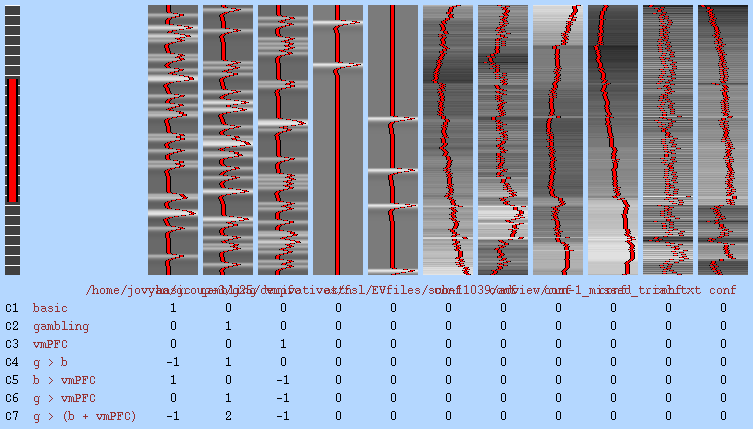

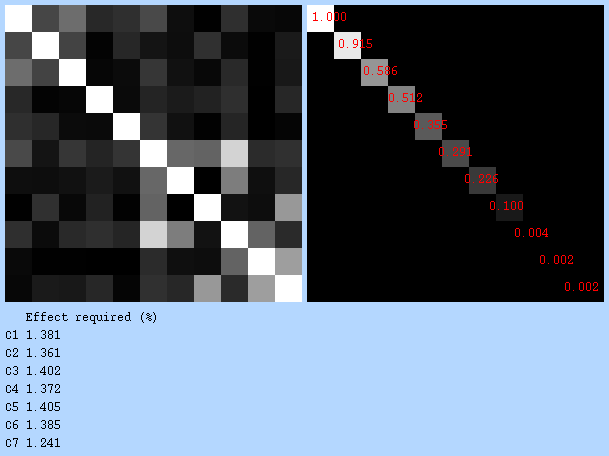

In [14]:
runtime_feat_output_dir = Path("/home/jovyan/group-3/g25/output/jupyter-notebook/_runtime/feat-demo/feat/sub-11039_task-adview_run-1_model-1_demo+++++.feat")

reg_dir = runtime_feat_output_dir / "reg"
reg_dir.mkdir(parents=True, exist_ok=True)

identity_mat = """1 0 0 0
0 1 0 0
0 0 1 0
0 0 0 1
"""

(reg_dir / "example_func2standard.mat").write_text(identity_mat)
(reg_dir / "standard2example_func.mat").write_text(identity_mat)

standard_candidates = [
    runtime_feat_output_dir / "mean_func.nii.gz",
    runtime_feat_output_dir / "example_func.nii.gz",
    runtime_feat_output_dir / "filtered_func_data.nii.gz",
]

for candidate in standard_candidates:
    if candidate.exists():
        shutil.copy2(candidate, reg_dir / "standard.nii.gz")
        print("Used for standard.nii.gz:", candidate.name)
        break

copy_pairs = [
    (runtime_fsf_path, FEAT_DEMO_DIR / "sub-11039_task-adview_run-1_model-1_demo.fsf"),
    (runtime_feat_output_dir / "design.png", FEAT_DEMO_DIR / "design.png"),
    (runtime_feat_output_dir / "design_cov.png", FEAT_DEMO_DIR / "design_cov.png"),
    (runtime_feat_output_dir / "example_func.nii.gz", FEAT_DEMO_DIR / "example_func.nii.gz"),
    (runtime_feat_output_dir / "stats" / "zstat1.nii.gz", FEAT_DEMO_DIR / "zstat1.nii.gz"),
    (runtime_feat_output_dir / "report.html", FEAT_DEMO_DIR / "report.html"),
    (runtime_feat_output_dir / "report_log.html", FEAT_DEMO_DIR / "report_log.html"),
    (runtime_feat_output_dir / "logs" / "feat1", FEAT_DEMO_DIR / "feat1.log"),
]

for src, dst in copy_pairs:
    if src.exists():
        shutil.copy2(src, dst)
        print("Copied:", src.name)

print("FEAT dir:", runtime_feat_output_dir)
print("Demo dir:", FEAT_DEMO_DIR)

if (FEAT_DEMO_DIR / "design.png").exists():
    display(Image(filename=str(FEAT_DEMO_DIR / "design.png")))
if (FEAT_DEMO_DIR / "design_cov.png").exists():
    display(Image(filename=str(FEAT_DEMO_DIR / "design_cov.png")))